In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/tarkwa_monthly_clean.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Features: Month_Num (1-12) and Year — matches Chapter 3 §3.15.1's GAM formula
X = df[["Month_Num", "Year"]].values
y = df["Monthly_Rainfall_mm"].values

# Same split point as SARIMA: first 228 rows = train, last 57 = test
split_idx = 228
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# pyGAM's Gamma distribution requires strictly positive targets (matches
# your Chapter 3 §3.4 rationale — rainfall is non-negative and right-skewed)
print("\nMin rainfall value in full dataset:", y.min())
print("Any zero or negative values?", (y <= 0).any())

Train shape: (228, 2) Test shape: (57, 2)

Min rainfall value in full dataset: 0.6000000000000001
Any zero or negative values? False


In [2]:
from pygam import GammaGAM, s

# s(0) = smooth term on Month_Num (column index 0), s(1) = smooth term on Year (column index 1)
# n_splines controls how flexible each smooth curve can be — 12 for Month_Num
# matches the natural monthly cycle (one "wiggle point" per calendar month)
gam = GammaGAM(s(0, n_splines=12) + s(1, n_splines=10))
gam.fit(X_train, y_train)

print("Model fitted successfully")
print("\nGAM Summary:")
print(gam.summary())

Model fitted successfully

GAM Summary:
GammaGAM                                                                                                  
=============================================== ==========================================================
Distribution:                         GammaDist Effective DoF:                                     12.7133
Link Function:                          LogLink Log Likelihood:                                 -1298.1473
Number of Samples:                          228 AIC:                                             2623.7212
                                                AICc:                                            2625.6132
                                                GCV:                                                0.4547
                                                Scale:                                              0.5711
                                                Pseudo R-Squared:                                   0.41

C:\Users\USER\AppData\Local\Temp\ipykernel_7396\2633783627.py:11: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = gam.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

print("GAM Test Set Performance:")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"  MAPE: {mape:.2f}%")
print(f"  R²:   {r2:.4f}")

print("\nYour reference GAM metrics were: RMSE 177.74, MAE 149.57, MAPE 435.50%, R² -1.5184")

GAM Test Set Performance:
  RMSE: 76.21
  MAE:  59.60
  MAPE: 140.63%
  R²:   0.5370

Your reference GAM metrics were: RMSE 177.74, MAE 149.57, MAPE 435.50%, R² -1.5184


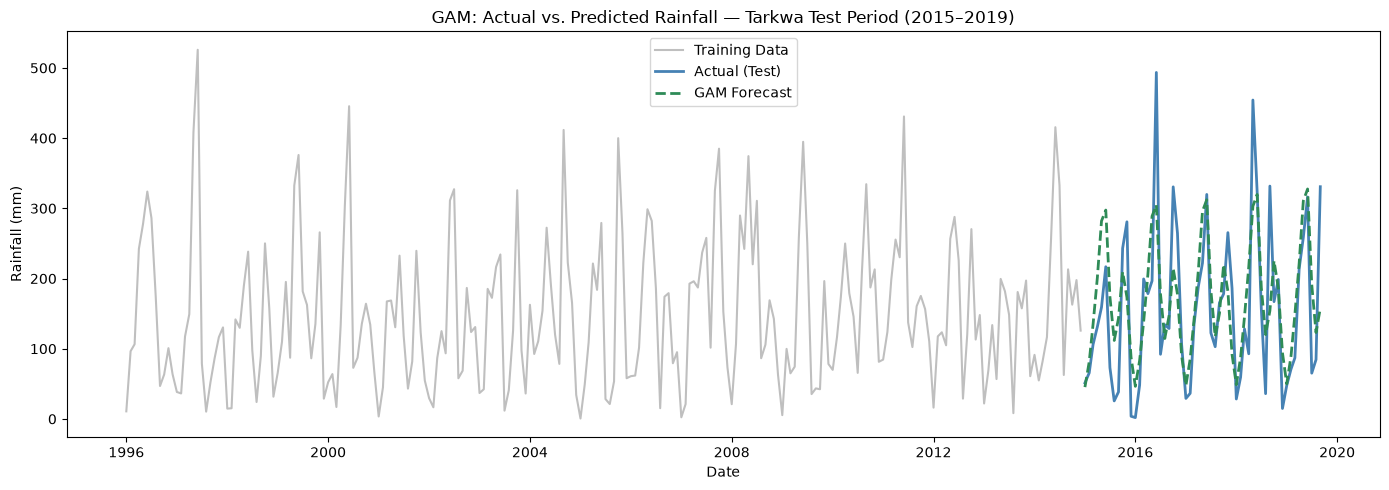

In [4]:
import matplotlib.pyplot as plt

test_dates = df["Date"].iloc[228:].reset_index(drop=True)

plt.figure(figsize=(14, 5))
plt.plot(df["Date"].iloc[:228], y_train, label="Training Data", color="gray", alpha=0.5)
plt.plot(test_dates, y_test, label="Actual (Test)", color="steelblue", linewidth=2)
plt.plot(test_dates, y_pred, label="GAM Forecast", color="seagreen", linewidth=2, linestyle="--")

plt.title("GAM: Actual vs. Predicted Rainfall — Tarkwa Test Period (2015–2019)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.savefig("../models/gam_actual_vs_predicted.png", dpi=150)
plt.show()

In [5]:
import joblib

MODEL_PATH = "../models/gam_model.pkl"
joblib.dump(gam, MODEL_PATH)

print(f"Model saved to {MODEL_PATH}")

# Reload check
loaded_gam = joblib.load(MODEL_PATH)
test_pred = loaded_gam.predict(X_test[:3])
print("\nReload check — first 3 test predictions from loaded model:")
print(test_pred)

Model saved to ../models/gam_model.pkl

Reload check — first 3 test predictions from loaded model:
[ 45.32654327  81.34493442 134.97897764]
